# Evaluation Plots for paper

In [1]:
!rsync -avz cluster.ies:/mnt/stud/work/phahn/repositories/dal_toolbox_new/baselines.db /home/phahn/repositories/dal-toolbox2.0/publications/adaptive_al/

receiving incremental file list

sent 20 bytes  received 67 bytes  58.00 bytes/sec
total size is 83,755,008  speedup is 962,701.24


In [2]:
import os
import mlflow
import numpy as np
import pylab as plt
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from collections import defaultdict
from pathlib import Path
from cycler import cycler
import time
import datetime

# Define a custom style dictionary
custom_style = {
    # Figure and axes
    "figure.figsize": (3, 2),
    "figure.dpi": 100,
    "axes.facecolor": "white",
    "axes.edgecolor": "lightgray",
    # Lines and markers
    "lines.linewidth": 1.5,
    "lines.markersize": 6,
    # Font settings
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    # Save figure settings
    "savefig.dpi": 300,
    # "axes.spines.top": False,
    # "axes.spines.right": False,
}

# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
mpl.rcParams.update(custom_style)
mpl.rcParams['axes.grid'] = True
mpl.rcParams["grid.linestyle"] = '--'
mpl.rcParams["grid.linewidth"] = .5
mpl.rcParams["grid.alpha"] = 0.7
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["#6C8EBF", "#D45D5D", "#5C985C", "#D9822B", "#65406B", "#DAB66C", "#A2D5C6", "#E699B3"])

plot_dir = Path('/home/phahn/paper_plots/adaptive_al/')
os.makedirs(plot_dir, exist_ok=True)

uri =   'sqlite://///home/phahn/repositories/dal-toolbox2.0/publications/adaptive_al/refine_new.db'
uri_2 = 'sqlite://///home/phahn/repositories/dal-toolbox2.0/publications/adaptive_al/baselines.db'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
client_2 = mlflow.tracking.MlflowClient(tracking_uri=uri_2)
print([(exp.name, datetime.date.fromtimestamp(exp.last_update_time/1000).strftime("%d-%m-%y")) for exp in client.search_experiments()])
print([(exp.name, datetime.date.fromtimestamp(exp.last_update_time/1000).strftime("%d-%m-%y")) for exp in client_2.search_experiments()])

2025/11/11 13:48:40 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/11/11 13:48:40 INFO mlflow.store.db.utils: Updating database tables
2025-11-11 13:48:40 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-11-11 13:48:40 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2025-11-11 13:48:40 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-11-11 13:48:40 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2025/11/11 13:48:40 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/11/11 13:48:40 INFO mlflow.store.db.utils: Updating database tables
2025-11-11 13:48:40 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-11-11 13:48:40 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2025-11-11 13:48:40 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-11-11 13:48:40 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


[('main_results_v1', '23-10-25'), ('Default', '23-10-25')]
[('ensemble-baselines-new', '01-11-25'), ('ensemble-baselines', '31-10-25'), ('baselines', '30-10-25'), ('Default', '30-10-25')]


In [3]:
def get_runs(uri, exp_name, query_list="", after=None, before=None, **kwargs):
    client = mlflow.tracking.MlflowClient(tracking_uri=uri)
    experiment_id = client.get_experiment_by_name(exp_name).experiment_id
    max_res = kwargs.get('max_results', 10000)
    runs = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list), max_results=max_res)
    if after is not None:
        runs = [run for run in runs if (run.info.end_time / 1000) > after]
    if before is not None:
        runs = [run for run in runs if (run.info.end_time / 1000) < before]
    runs = sorted(runs, key=lambda run: int(run.data.params['random_seed']))
    return runs


def get_metric(run, uri, metric):
    client = mlflow.tracking.MlflowClient(uri)
    m_values = [m.value for m in client.get_metric_history(run.info.run_id, metric)]
    return m_values

def get_avg_lc(runs, uri, metric='accuracy', return_std=False):
    lcs = []
    for run in runs:
        m_values = get_metric(run, uri, metric)
        if len(m_values) == 0:
            print(f'No metric values found for run {run.info.run_id}.')
        if len(m_values) != 21:
            continue
        lcs.append(m_values)
    avg_lc = np.mean(lcs, axis=0)
    if return_std:
        std_lc = np.std(lcs, axis=0)
        return avg_lc, std_lc 
    return avg_lc
    
def get_axis_from_run(run):
    acq_size = eval(run.data.params['dataset.acq_size'])
    num_acq = eval(run.data.params['dataset.num_acq'])
    budget = acq_size + num_acq*acq_size
    axis = np.arange(acq_size, budget+1, acq_size)
    return axis

In [17]:
baselines_uri = 'sqlite:////home/phahn/repositories/dal-toolbox2.0/publications/adaptive_al/baselines.db'
ensemble_uri = baselines_uri
refine_uri = 'sqlite://///home/phahn/repositories/dal-toolbox2.0/publications/adaptive_al/refine_new.db'

baselines_exp_name = 'baselines'
ensemble_exp_name = 'ensemble-baselines-new'
refine_exp_name = 'main_results_v1'

baselines_strats = ['random', 'margin', 'badge', 'typiclust', 'max_herding', 'uncertainty_herding', 'alfamix', 'dropquery', 'bait']
ensemble_strats = ['tcm', 'tailor2', 'select_al', 'autoal2']
refine_strats = ['refine']
all_strategies = baselines_strats + ensemble_strats + refine_strats

datasets = ['cifar10', 'dopanim', 'cifar100', 'snacks']#, 'food101', 'tiny_imagenet'] #TODO: Await AutoAL results
backbones = ['dinov2', 'clip', 'dinov3']

all_lcs = {}

for uri, exp_name, strats in zip([baselines_uri, ensemble_uri, refine_uri], [baselines_exp_name, ensemble_exp_name, refine_exp_name], [baselines_strats, ensemble_strats, refine_strats]):
    for bb in backbones:
        if bb not in all_lcs:
            all_lcs[bb] = {}
        for dset in datasets:
            if dset not in all_lcs[bb]:
                all_lcs[bb][dset] = {}
            for strat in strats:
                all_lcs[bb][dset][strat] = {}
                runs = get_runs(uri, exp_name, [f"parameter.dataset.name = '{dset}'", f"parameter.al.strategy = '{strat}'", f"parameter.model.backbone = '{bb}'"])
                runs = sorted(runs, key=lambda run: int(run.data.params['random_seed']))
                for run in runs:
                    seed = run.data.params['random_seed']
                    accs = get_metric(run, uri, 'accuracy')
                    if len(accs) == 21: #TODO: Fixme hardcoded
                        all_lcs[bb][dset][strat][seed] = accs
                    else:
                        print("Run with not enough acc values?=", bb, dset, strat, seed)

Run with not enough acc values?= dinov2 cifar10 random 5
Run with not enough acc values?= dinov3 snacks bait 6
Run with not enough acc values?= dinov2 cifar10 tailor2 5
Run with not enough acc values?= dinov2 cifar10 tailor2 10
Run with not enough acc values?= dinov3 cifar10 tailor2 1
Run with not enough acc values?= dinov3 cifar10 tailor2 2
Run with not enough acc values?= dinov3 cifar10 tailor2 5


In [18]:
# Load in one run manually as i saved it in the wrong experiment

run = get_runs(baselines_uri, 'ensemble-baselines-new', [f"parameter.dataset.name = 'snacks'", f"parameter.al.strategy = 'bait'", f"parameter.model.backbone = 'dinov3'", f"parameter.random_seed = '6'"])
all_lcs["dinov3"]["snacks"]["bait"]["6"] = get_metric(run[0], baselines_uri, 'accuracy')

In [19]:
all_lcs_array = {}
seeds = [str(i) for i in range(1,11)]

for bb in backbones:
    all_lcs_array[bb] = {}
    for dset in datasets:
        all_lcs_array[bb][dset] = {}
        for strat in all_strategies:
            if len(all_lcs[bb][dset][strat].values()) == 0:
                print("Experiment Missing:", bb, dset, strat)
            elif len(all_lcs[bb][dset][strat].values()) != 10:
                for seed in seeds:
                    if seed not in all_lcs[bb][dset][strat]:
                        print(f'"{strat},{dset},{bb},{seed}"')
            else:
                all_lcs_array[bb][dset][strat] = np.array(list(all_lcs[bb][dset][strat].values()))

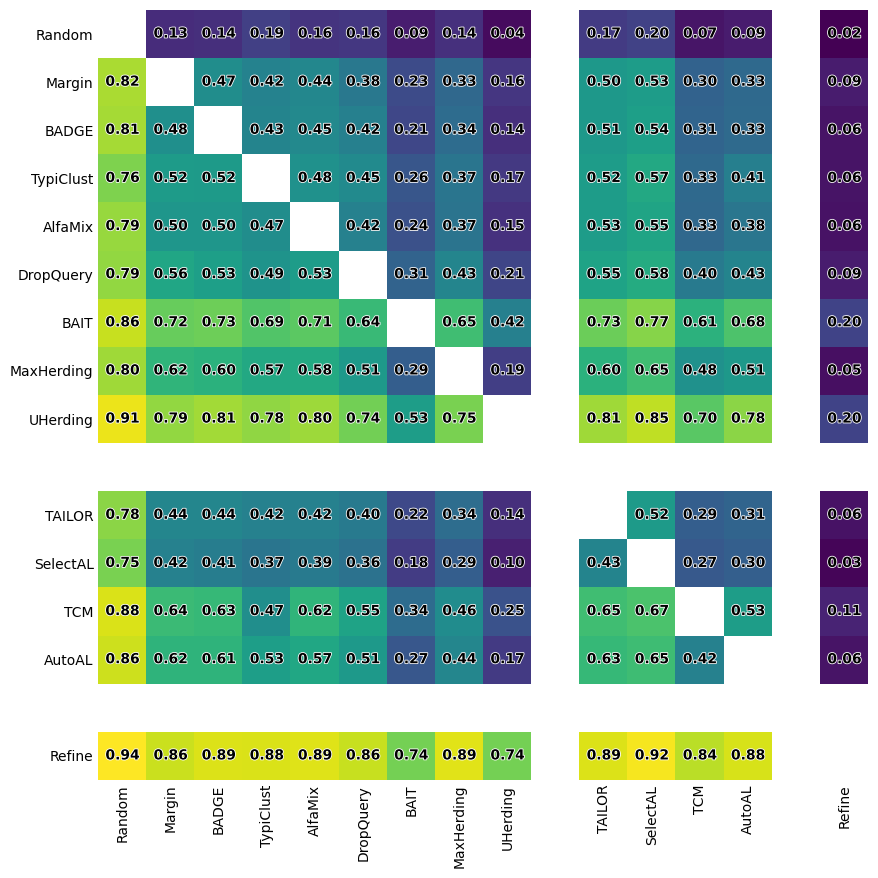

In [21]:
from scipy import stats
from matplotlib import patheffects

def create_pairwise_comparison_matrix(lc_dict, alpha=0.05):
    strategy_names = list(lc_dict.keys())
    n_strategies = len(strategy_names)
    
    # Initialize comparison matrix
    matrix = np.zeros((n_strategies, n_strategies))
    
    # Get number of cycles from first strategy
    num_seeds, num_cycles = list(lc_dict.values())[0].shape
    
    # Compare each pair of lc_dict
    for i, strat_i in enumerate(strategy_names):
        for j, strat_j in enumerate(strategy_names):
            if i == j:
                continue
            
            curves_i = lc_dict[strat_i]
            curves_j = lc_dict[strat_j]
            
            wins = 0
            for cycle in range(1, num_cycles): # first cycle is identical due to same init set
                for seed in range(num_seeds):
                    acc_i = curves_i[seed, cycle]
                    acc_j = curves_j[seed, cycle]

                    if acc_i > acc_j:
                        wins += 1
                
                # Paired t-test and check if i significantly outperforms j
                # t_stat, p_value = stats.ttest_rel(acc_i, acc_j)
                # if p_value < alpha and np.mean(acc_i) > np.mean(acc_j):
                #     wins += 1
            matrix[i, j] = wins / (num_cycles*num_seeds)
    
    return matrix, strategy_names

all_models = backbones

all_mats = []
for model in all_models:
    for dataset in datasets:
        mat, names = create_pairwise_comparison_matrix(all_lcs_array[model][dataset])
        all_mats.append(mat)
avg_mat = np.mean(all_mats, axis=0)

strat_order = ['random', 'margin', 'badge', 'typiclust', 'alfamix', 'dropquery', 'bait', 'max_herding', 'uncertainty_herding', 'tailor2', 'select_al', 'tcm', 'autoal2', 'refine']
strat_presentation_names = {'random':"Random", 'margin':'Margin', 'alfamix':'AlfaMix', 'badge':'BADGE', 'typiclust':'TypiClust', 'dropquery':'DropQuery', 'max_herding':'MaxHerding',
                            'uncertainty_herding':'UHerding', 'tailor2':'TAILOR', 'autoal2':'AutoAL', 'tcm':'TCM', 'select_al':'SelectAL', 'bait':'BAIT', 'refine':'Refine'}
indices_order = [names.index(s) for s in strat_order]

avg_mat = avg_mat[np.ix_(indices_order, indices_order)]
names = [strat_presentation_names[names[i]] for i in indices_order]

# --- Make diagonal empty ---
np.fill_diagonal(avg_mat, np.nan)

# --- Define group boundaries ---
# We want: [ first part | gap | 4 methods | gap | last one ]
# i.e., one gap before index -5 (5th from last) and one gap before index -1 (last)
gap_indices = [-5, -1]
gap_value = np.nan

# --- Insert gaps (rows + columns) ---
avg_mat_gap = avg_mat.copy()
# Convert negative indices to absolute positions before insertion
abs_gap_indices = sorted([len(avg_mat) + i if i < 0 else i for i in gap_indices])
abs_gap_indices[1] += 1
for idx in abs_gap_indices:
    avg_mat_gap = np.insert(avg_mat_gap, idx, gap_value, axis=0)
    avg_mat_gap = np.insert(avg_mat_gap, idx, gap_value, axis=1)

# --- Build names with gaps inserted ---
names_with_gaps = names.copy()
for idx in abs_gap_indices:
    names_with_gaps.insert(idx, None)

# --- Custom colormap: white for NaNs (the gaps + diagonal) ---
cmap = plt.cm.viridis.copy()
cmap.set_bad(color='white')

plt.figure(figsize=(12, 10))
im = plt.imshow(avg_mat_gap, cmap=cmap)
plt.grid(False)

# --- Add numeric labels, skip NaNs ---
for i in range(avg_mat_gap.shape[0]):
    for j in range(avg_mat_gap.shape[1]):
        if not np.isnan(avg_mat_gap[i, j]):
            text = plt.text(j, i, f'{avg_mat_gap[i, j]:.2f}',
                            ha="center", va="center", color="black",
                            fontsize=10, fontweight='bold',
                            path_effects=[
                                patheffects.Stroke(linewidth=1.2, foreground='white'),
                                patheffects.Normal()
                            ])

# --- Tick labels: skip the gap positions ---
tick_positions = [i for i, n in enumerate(names_with_gaps) if n is not None]
tick_labels = [n for n in names_with_gaps if n is not None]

plt.xticks(tick_positions, tick_labels, rotation=90)
plt.yticks(tick_positions, tick_labels)

# --- Remove borders and tick marks ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tick_params(axis='both', which='both', length=0)

plt.show()

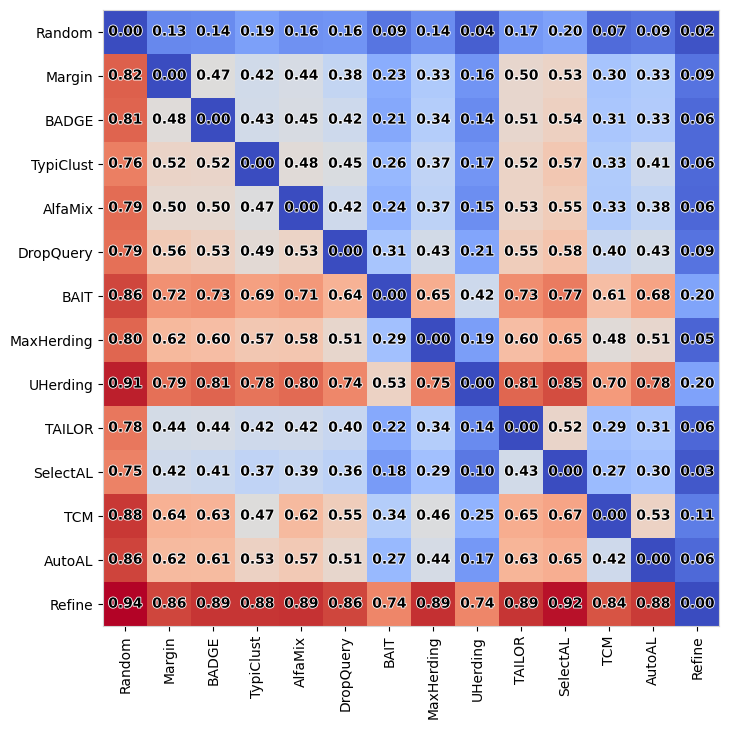

In [46]:
from scipy import stats
from matplotlib import patheffects

def create_pairwise_comparison_matrix(lc_dict, alpha=0.05):
    strategy_names = list(lc_dict.keys())
    n_strategies = len(strategy_names)
    
    # Initialize comparison matrix
    matrix = np.zeros((n_strategies, n_strategies))
    
    # Get number of cycles from first strategy
    num_seeds, num_cycles = list(lc_dict.values())[0].shape
    
    # Compare each pair of lc_dict
    for i, strat_i in enumerate(strategy_names):
        for j, strat_j in enumerate(strategy_names):
            if i == j:
                continue
            
            curves_i = lc_dict[strat_i]
            curves_j = lc_dict[strat_j]
            
            wins = 0
            for cycle in range(1, num_cycles): # first cycle is identical due to same init set
                for seed in range(num_seeds):
                    acc_i = curves_i[seed, cycle]
                    acc_j = curves_j[seed, cycle]

                    if acc_i > acc_j:
                        wins += 1
                
                # Paired t-test and check if i significantly outperforms j
                # t_stat, p_value = stats.ttest_rel(acc_i, acc_j)
                # if p_value < alpha and np.mean(acc_i) > np.mean(acc_j):
                #     wins += 1
            matrix[i, j] = wins / (num_cycles*num_seeds)
    
    return matrix, strategy_names

all_models = backbones
strat_order = ['random', 'margin', 'badge', 'typiclust', 'alfamix', 'dropquery', 'bait', 'max_herding', 'uncertainty_herding', 'tailor2', 'select_al', 'tcm', 'autoal2', 'refine']
all_mats = []
for model in all_models:
    for dataset in datasets:
        mat, names = create_pairwise_comparison_matrix(all_lcs_array[model][dataset])
        all_mats.append(mat)
avg_mat = np.mean(all_mats, axis=0)


strat_presentation_names = {'random':"Random", 'margin':'Margin', 'alfamix':'AlfaMix', 'badge':'BADGE', 'typiclust':'TypiClust', 'dropquery':'DropQuery', 'max_herding':'MaxHerding',
                            'uncertainty_herding':'UHerding', 'tailor2':'TAILOR', 'autoal2':'AutoAL', 'tcm':'TCM', 'select_al':'SelectAL', 'bait':'BAIT', 'refine':'Refine'}
indices_order = [names.index(s) for s in strat_order]

avg_mat = avg_mat[np.ix_(indices_order, indices_order)]
names = [strat_presentation_names[names[i]] for i in indices_order]

plt.figure(figsize=(10, 8))
plt.grid()
plt.imshow(avg_mat, cmap='coolwarm')
for i in range(len(names)):
    for j in range(len(names)):
        text = plt.text(j, i, f'{avg_mat[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=10, fontweight='bold')
        text.set_path_effects([patheffects.Stroke(linewidth=1.2, foreground='white'), patheffects.Normal()])

plt.xticks(range(len(mat)), names, rotation=90)
plt.yticks(range(len(mat)), names)
#plt.savefig(plot_dir / f'avg_pairwise_comparison_matrix.pdf', bbox_inches='tight')
plt.show()

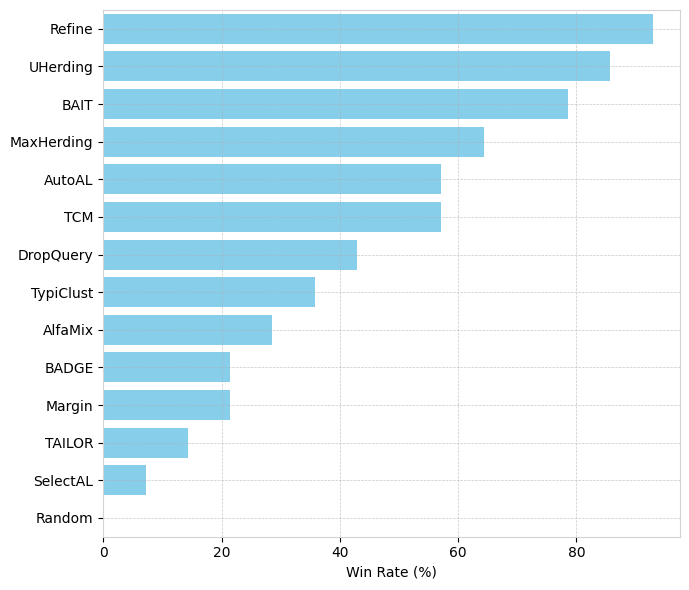

In [50]:
# Compute win rate (fraction of pairwise wins)
win_rate = np.nanmean(avg_mat > 0.5, axis=1) * 100

# --- Sort by win rate ---
sorted_indices = np.argsort(win_rate)        # ascending order
sorted_names = [names[i] for i in sorted_indices]
sorted_win_rate = win_rate[sorted_indices]

# --- Plot ---
plt.figure(figsize=(7, 6))
plt.barh(sorted_names, sorted_win_rate, color='skyblue')
plt.xlabel("Win Rate (%)")
plt.gca().invert_yaxis()  # optional: highest at top
plt.tight_layout()
plt.ylim(-.5, 13.5)
plt.show()

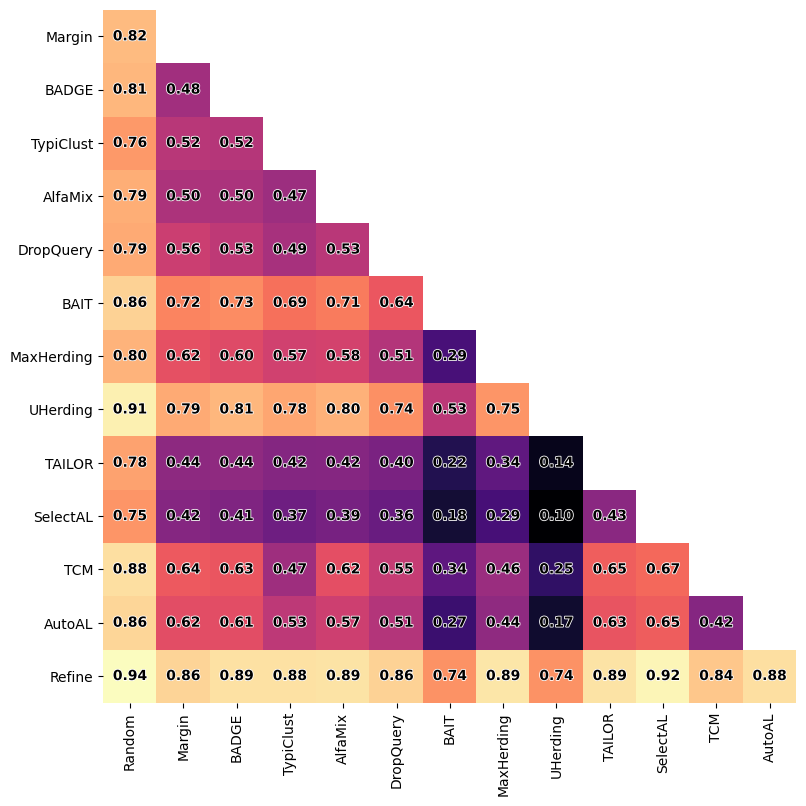

In [41]:
new_avg_mat = avg_mat[1:,][:,:-1]
mask = np.triu(np.ones_like(new_avg_mat, dtype=bool), k=1)  # upper triangle mask

plt.figure(figsize=(10, 9))
plt.imshow(np.ma.array(new_avg_mat, mask=mask), cmap='magma')
for i in range(len(names)-1):
    for j in range(len(names)-1):
        if i >= j:
            text = plt.text(j, i, f'{new_avg_mat[i, j]:.2f}',
                        ha="center", va="center", color="black", fontsize=10, fontweight='bold')
            text.set_path_effects([patheffects.Stroke(linewidth=1.2, foreground='white'), patheffects.Normal()])
plt.xticks(range(len(names)-1), names[:-1], rotation=90)
plt.yticks(range(len(names)-1), names[1:])
plt.grid(False)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
plt.show()

KeyError: 'food101'

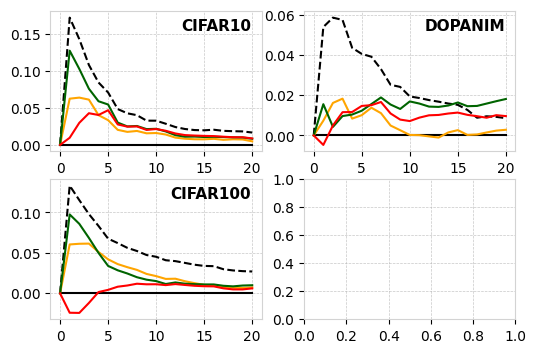

In [11]:
plot_kwargs = {
    'random':               dict(ls='-' , color='black', label='Random'),
    'refine':               dict(ls='--', color='black', label='Refine'),
    'tcm':                  dict(ls='-', color='darkgreen', label='TCM'),
    'tailor2':              dict(ls='-', color='red', label='TAILOR'),
    'select_al':            dict(ls='-', color='orange', label='SelectAL'),
}
for model in backbones:
    datasets = ['cifar10', 'dopanim', 'cifar100', 'food101']
    strats = ['random', 'refine', 'select_al', 'tcm', 'tailor2']

    fig, ax = plt.subplots(figsize=(6, 4), ncols=2, nrows=2)
    ax = ax.flatten()

    absolute = False
    for i_ds, ds in enumerate(datasets):
        plt.sca(ax[i_ds])
        avg_lc_random = np.mean(all_lcs_array[model][ds]['random'], 0)
        for strat in strats:
            avg_lc = np.mean(all_lcs_array[model][ds][strat], 0)
            target = avg_lc 
            target -= 0 if absolute else avg_lc_random 
            plt.plot(target, **plot_kwargs[strat])

        text_y_pos = 0.15 if absolute else 0.95
        ax[i_ds].text(0.95, text_y_pos, ds.upper(), 
                    transform=ax[i_ds].transAxes,
                    fontsize=11, fontweight='bold',
                    verticalalignment='top',
                    horizontalalignment='right')

    plt.tight_layout()
    ax[0].legend(bbox_to_anchor=(0, 1.3), loc='upper left', ncol=5)
    plt.show()